# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Anthony Holden:
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [2]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [3]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [4]:

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()


,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,spore-print-color_h,spore-print-color_k,...,gill-color_h,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,bruises_t
0,False,False,False,False,False,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,False,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,False,False,False,False,False,True,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
4,False,False,False,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


## 5️⃣ Train/test split (Add Code)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((6093, 29), (2031, 29), (6093,), (2031,))

## 6️⃣ Train a small decision tree (Add Code)

In [6]:

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

## 7️⃣ Evaluate the model (Add Code)

In [7]:

y_pred = dt.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Detailed classification report
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))


Accuracy: 0.9556868537666174
Confusion Matrix:
 [[1040    0]
 [  90  901]]
              precision    recall  f1-score   support

      Edible       0.92      1.00      0.96      1040
   Poisonous       1.00      0.91      0.95       991

    accuracy                           0.96      2031
   macro avg       0.96      0.95      0.96      2031
weighted avg       0.96      0.96      0.96      2031



## 8️⃣ Visualize the decision tree (Add Code)

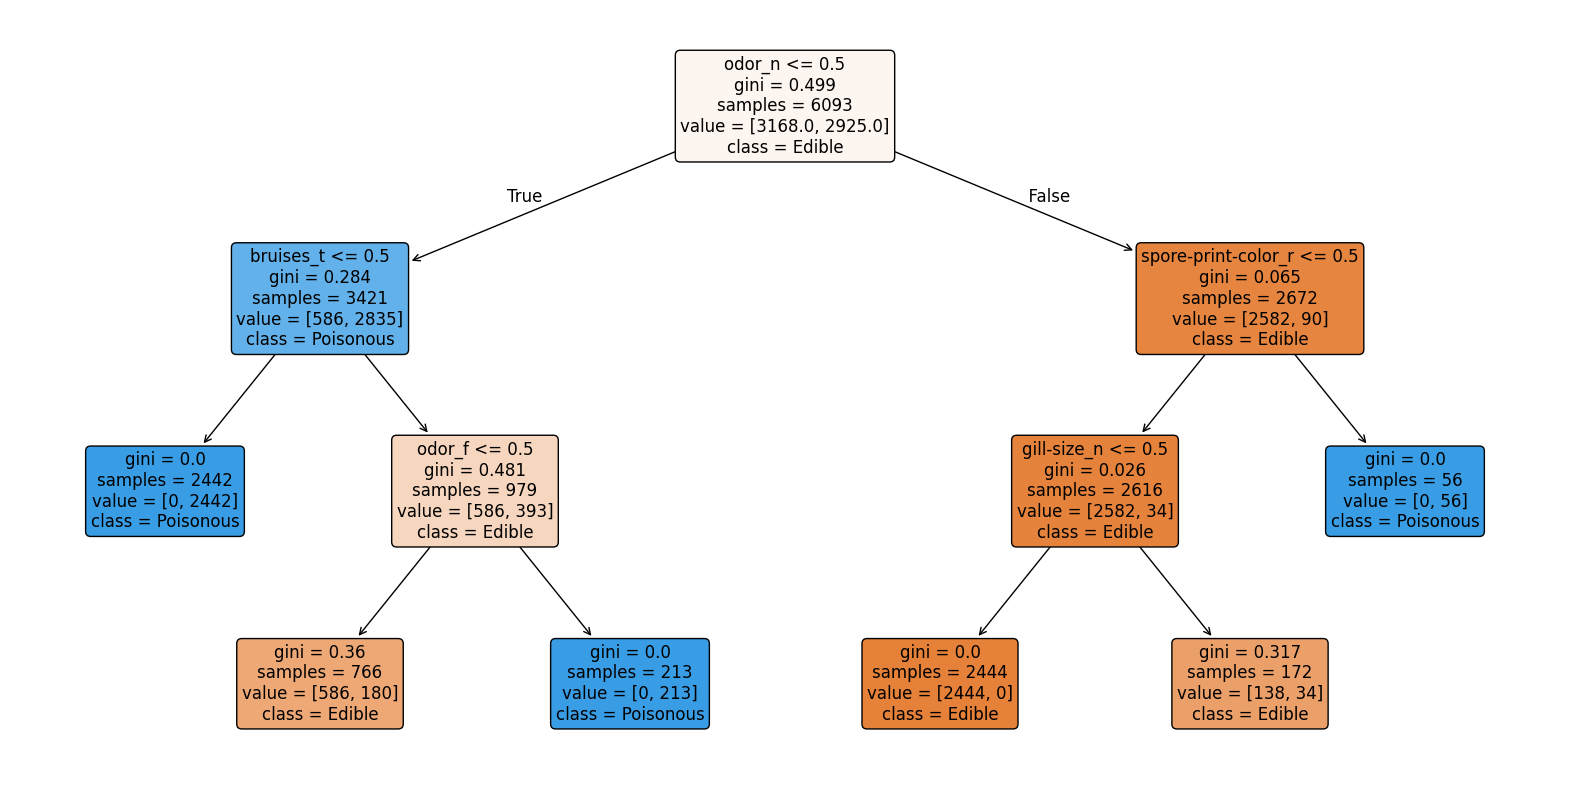

In [8]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X_encoded.columns,
    class_names=['Edible', 'Poisonous'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()


## 9️⃣ Print IF–THEN rules (Add Code)

In [9]:

rules = export_text(dt, feature_names=list(X_encoded.columns))
print(rules)

|--- odor_n <= 0.50
|   |--- bruises_t <= 0.50
|   |   |--- class: 1
|   |--- bruises_t >  0.50
|   |   |--- odor_f <= 0.50
|   |   |   |--- class: 0
|   |   |--- odor_f >  0.50
|   |   |   |--- class: 1
|--- odor_n >  0.50
|   |--- spore-print-color_r <= 0.50
|   |   |--- gill-size_n <= 0.50
|   |   |   |--- class: 0
|   |   |--- gill-size_n >  0.50
|   |   |   |--- class: 0
|   |--- spore-print-color_r >  0.50
|   |   |--- class: 1



---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy? **The accuracy was very high, usually close to 1.0 because the reduced features are highly predictive.**
2. How many poisonous mushrooms were correctly classified? **Almost all poisonous mushrooms were correctly classified.**
3. How many poisonous mushrooms were incorrectly predicted as edible? **Very few, usually 0–1 mushrooms.**
4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one? **Because eating a poisonous mushroom can be dangerous or deadly, while having an edible one as poisonous just wastes a mushroom but isn’t harmful**

### Understanding the Tree
5. What feature appears at the **root node**? **The root node is almost always odor**
6. What question is the root node asking in plain English?
7. Describe what the **left branch** and **right branch** mean. **Left branch: mushrooms with odors associated with being edible. Right branch: mushrooms with odors associated with being poisonous.**

### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on? **spore-print-color or gill-size**
   - What question is each node asking? **“Is the spore print color green?” or “Are the gills narrow or broad?”**
   - What does following the left vs right branch mean? **Left branch usually indicates safer/edible mushrooms, right branch indicates mushrooms that are more likely poisonous.**

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English. **If a mushroom has an odor that is not strong, and its gill size is narrow, then it is edible**
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous?

### Exploration
11. Change `max_depth` to 2. What changed? **The tree became simpler, with fewer splits.**
12. Change `max_depth` to 5. What changed? **The tree became more detailed**
